# RQ8 Query Space Visualization

这个 notebook 用于把 RQ8 的二维查询窗口画到 **归一化数据空间 [0,1]x[0,1]**，便于对比不同 aspect ratio 的查询形状。

支持两种方式：
1. 按条件自动选一组 spec（推荐）。
2. 手工给 spec 路径列表。


In [1]:
from __future__ import annotations

import datetime as dt
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import yaml


In [2]:
def find_repo_root(start: Path) -> Path:
    for cand in [start, *start.parents]:
        if (cand / "workloads").exists() and (cand / "workload_spec").exists():
            return cand
    raise FileNotFoundError("Could not find repo root containing workloads/ and workload_spec/")

ROOT = find_repo_root(Path.cwd())
STATS_PATH = ROOT / "workloads" / "stats" / "tpch_16_stats.yaml"
SPEC_DIR = ROOT / "workload_spec" / "tpch_rq8"
FILLED_YAML_DIR = ROOT / "workloads" / "rq8_plot" / "yaml"
FILLED_SQL_DIR = ROOT / "workloads" / "rq8_plot" / "sql"

FILLED_YAML_DIR.mkdir(parents=True, exist_ok=True)
FILLED_SQL_DIR.mkdir(parents=True, exist_ok=True)

ROOT, STATS_PATH, SPEC_DIR


(PosixPath('/home/unimelb.edu.au/guanlil1/Documents/lakehouse'),
 PosixPath('/home/unimelb.edu.au/guanlil1/Documents/lakehouse/workloads/stats/tpch_16_stats.yaml'),
 PosixPath('/home/unimelb.edu.au/guanlil1/Documents/lakehouse/workload_spec/tpch_rq8'))

In [3]:
def _infer_type(raw: str) -> str:
    raw = (raw or "").lower()
    if "date" in raw:
        return "date"
    if any(k in raw for k in ["int", "long"]):
        return "int"
    if any(k in raw for k in ["float", "double", "decimal", "numeric"]):
        return "number"
    return "string"

def _epochms_to_date(v):
    if v is None:
        return None
    if isinstance(v, (int, float)):
        return dt.date.fromtimestamp(float(v) / 1000.0)
    if isinstance(v, dt.date):
        return v
    return dt.date.fromisoformat(str(v))

def _to_numeric(v, tp: str) -> float:
    if tp == "date":
        d = _epochms_to_date(v)
        return float(d.toordinal())
    return float(v)

def load_stats_domains(stats_path: Path):
    data = yaml.safe_load(stats_path.read_text())
    schema = {k: (v or "").lower() for k, v in (data.get("schema") or {}).items()}

    domains = {}
    for col, meta in (data.get("columns") or {}).items():
        tp = _infer_type(schema.get(col) or meta.get("kind"))
        lo, hi = meta.get("min"), meta.get("max")
        if lo is None or hi is None:
            continue
        domains[col] = {
            "type": tp,
            "lo_raw": lo,
            "hi_raw": hi,
            "lo_num": _to_numeric(lo, tp),
            "hi_num": _to_numeric(hi, tp),
        }
    return domains

DOMAINS = load_stats_domains(STATS_PATH)
len(DOMAINS), DOMAINS.get("l_extendedprice"), DOMAINS.get("l_quantity")


(12,
 {'type': 'number',
  'lo_raw': 910.91,
  'hi_raw': 103844.5,
  'lo_num': 910.91,
  'hi_num': 103844.5},
 {'type': 'number',
  'lo_raw': 1.0,
  'hi_raw': 50.0,
  'lo_num': 1.0,
  'hi_num': 50.0})

In [4]:
def load_spec(path: Path):
    data = yaml.safe_load(path.read_text())
    tpl = (data.get("templates") or [])[0]
    rules = tpl.get("interval_rules") or []
    if len(rules) != 2:
        raise ValueError(f"Expected 2 interval rules in {path}, got {len(rules)}")

    return {
        "path": path,
        "name": path.stem,
        "meta": data.get("meta") or {},
        "template": tpl,
        "rules": rules,
    }

def discover_specs(query_id=None, selectivity_label=None, aspect_labels=None):
    infos = []
    for p in sorted(SPEC_DIR.glob("spec_tpch_RQ8_*.yaml")):
        info = load_spec(p)
        meta = info["meta"]
        if query_id and meta.get("query") != query_id:
            continue
        if selectivity_label and (meta.get("selectivity") or {}).get("label") != selectivity_label:
            continue
        if aspect_labels and (meta.get("aspect_ratio") or {}).get("label") not in set(aspect_labels):
            continue
        infos.append(info)
    return infos

def fill_spec_if_needed(spec_path: Path, force=False):
    out_yaml = FILLED_YAML_DIR / f"{spec_path.stem}.yaml"
    out_sql_dir = FILLED_SQL_DIR / spec_path.stem
    has_sql = out_sql_dir.exists() and any(out_sql_dir.glob("*.sql"))

    if force or (not out_yaml.exists()) or (not has_sql):
        out_sql_dir.mkdir(parents=True, exist_ok=True)
        cmd = [
            "python", "-m", "wlg.cli", "fill",
            "--spec", str(spec_path),
            "--stats", str(STATS_PATH),
            "--out", str(out_yaml),
            "--sql-dir", str(out_sql_dir),
        ]
        subprocess.run(cmd, check=True)
    return out_yaml

def fill_specs(spec_infos, force=False):
    outputs = []
    for info in spec_infos:
        out_yaml = fill_spec_if_needed(info["path"], force=force)
        outputs.append((info, out_yaml))
    return outputs


In [5]:
# 推荐：先选定一个可比组（同 query + 同 selectivity，不同 aspect）
GROUP_QUERY = "Q8_N2_4"
GROUP_SELECTIVITY = "S1"
GROUP_ASPECTS = ["A4_1", "A16_1", "A1_4", "A1_16"]

spec_group = discover_specs(
    query_id=GROUP_QUERY,
    selectivity_label=GROUP_SELECTIVITY,
    aspect_labels=GROUP_ASPECTS,
)

[(x['name'], (x['meta'].get('aspect_ratio') or {}).get('label')) for x in spec_group]


[('spec_tpch_RQ8_Q8_N2_4_S1_A16_1', 'A16_1'),
 ('spec_tpch_RQ8_Q8_N2_4_S1_A1_16', 'A1_16'),
 ('spec_tpch_RQ8_Q8_N2_4_S1_A1_4', 'A1_4'),
 ('spec_tpch_RQ8_Q8_N2_4_S1_A4_1', 'A4_1')]

In [6]:
# 如果你要手动指定 spec，可用下面这种方式覆盖 spec_group
# manual = [
#     SPEC_DIR / "spec_tpch_RQ8_Q8_N2_4_S1_A4_1.yaml",
#     SPEC_DIR / "spec_tpch_RQ8_Q8_N2_4_S1_A1_4.yaml",
# ]
# spec_group = [load_spec(p) for p in manual]

filled_group = fill_specs(spec_group, force=False)
[(info['name'], out.name) for info, out in filled_group]


[('spec_tpch_RQ8_Q8_N2_4_S1_A16_1', 'spec_tpch_RQ8_Q8_N2_4_S1_A16_1.yaml'),
 ('spec_tpch_RQ8_Q8_N2_4_S1_A1_16', 'spec_tpch_RQ8_Q8_N2_4_S1_A1_16.yaml'),
 ('spec_tpch_RQ8_Q8_N2_4_S1_A1_4', 'spec_tpch_RQ8_Q8_N2_4_S1_A1_4.yaml'),
 ('spec_tpch_RQ8_Q8_N2_4_S1_A4_1', 'spec_tpch_RQ8_Q8_N2_4_S1_A4_1.yaml')]

In [7]:
def _norm(v, domain):
    lo, hi = domain['lo_num'], domain['hi_num']
    x = _to_numeric(v, domain['type'])
    if hi <= lo:
        return 0.0
    return max(0.0, min(1.0, (x - lo) / (hi - lo)))

def rectangles_from_filled(spec_info, filled_yaml_path: Path):
    workload = yaml.safe_load(filled_yaml_path.read_text()).get('workload') or []
    rules = spec_info['rules']

    c1, c2 = rules[0]['column'], rules[1]['column']
    d1, d2 = DOMAINS[c1], DOMAINS[c2]

    rows = []
    for i, e in enumerate(workload, 1):
        p = e.get('params') or {}
        x_lo = _norm(p[rules[0]['lo']], d1)
        x_hi = _norm(p[rules[0]['hi']], d1)
        y_lo = _norm(p[rules[1]['lo']], d2)
        y_hi = _norm(p[rules[1]['hi']], d2)
        rows.append({
            'idx': i,
            'x': min(x_lo, x_hi),
            'y': min(y_lo, y_hi),
            'w': abs(x_hi - x_lo),
            'h': abs(y_hi - y_lo),
            'col_x': c1,
            'col_y': c2,
            'aspect_label': (spec_info['meta'].get('aspect_ratio') or {}).get('label'),
            'spec_name': spec_info['name'],
        })
    return rows

def _pretty_aspect_label(raw: str) -> str:
    if not raw:
        return "unknown"
    if raw.startswith("A") and "_" in raw:
        body = raw[1:]
        left, right = body.split("_", 1)
        if left.isdigit() and right.isdigit():
            return f"{int(left)}:{int(right)}"
    return raw

def plot_rectangles_overlay(filled_group, alpha=0.28):
    groups = []
    for spec_info, filled_yaml in filled_group:
        rows = rectangles_from_filled(spec_info, filled_yaml)
        groups.append((spec_info, rows))

    if not groups:
        raise ValueError('No data to plot')

    fig, ax = plt.subplots(1, 1, figsize=(8.0, 7.0))
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

    legend_handles = []
    for i, (spec_info, rows) in enumerate(groups):
        color = colors[i % len(colors)]
        ar = spec_info['meta'].get('aspect_ratio') or {}
        aspect_label = _pretty_aspect_label(ar.get('label') or f'group_{i+1}')

        for r in rows:
            rect = Rectangle(
                (r['x'], r['y']), r['w'], r['h'],
                fill=True, facecolor=color, edgecolor=color,
                alpha=alpha, linewidth=1.1
            )
            ax.add_patch(rect)

        # one proxy handle per aspect for clean legend
        proxy = Rectangle((0, 0), 1, 1, facecolor=color, edgecolor=color, alpha=0.6)
        legend_handles.append((proxy, aspect_label))

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_xlabel('Dimension 1 (normalized)')
    ax.set_ylabel('Dimension 2 (normalized)')
    ax.set_title('RQ8 query windows in normalized data space (overlay)')

    unique = {}
    for h, l in legend_handles:
        if l not in unique:
            unique[l] = h
    ax.legend(list(unique.values()), list(unique.keys()), title='Aspect ratio', loc='upper right', frameon=True)

    plt.tight_layout()
    plt.show()


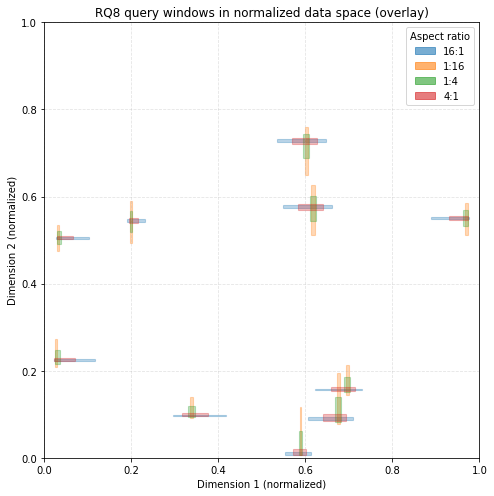

In [8]:
plot_rectangles_overlay(filled_group, alpha=0.30)


## Notes

- 图里每个矩形是一条已实例化查询（fill 后的 lo/hi）。
- 坐标是相对 domain 的归一化值，便于跨类型（date/number）对比。
- 建议固定 `query + selectivity + column_config`，只比较 aspect，这样最科学。
